# HW 4: kNN

In [34]:
import warnings
warnings.filterwarnings('ignore')

import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve,auc
from sklearn import metrics
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from tqdm.notebook import tqdm

In [2]:
%pylab inline
%load_ext pycodestyle_magic

Populating the interactive namespace from numpy and matplotlib


## Import data

In [5]:
df = pd.read_csv('data/credit_scoring_train.csv')
df_test = pd.read_csv('data/credit_scoring_test.csv')

In [6]:
df.head()

,client_id,DIR,Age,NumLoans,NumRealEstateLoans,NumDependents,Num30-59Delinquencies,Num60-89Delinquencies,Income,BalanceToCreditLimit,Delinquent90
0,0,0.177772,50.5,11,0,3.0,2,0,5511.073207,0.898558,0
1,1,0.278636,65.3,9,2,2.0,0,0,4544.015711,0.010220,0
2,2,0.000000,55.4,0,0,0.0,0,0,NaN,1.005478,0
3,3,0.285555,53.4,12,2,1.0,0,0,13253.922692,1.309580,0
4,4,0.592800,56.5,10,6,0.0,0,0,12581.109054,0.045905,0


### Checking for na values

In [7]:
df.isnull().sum()

client_id                    0
DIR                          0
Age                          0
NumLoans                     0
NumRealEstateLoans           0
NumDependents             1527
Num30-59Delinquencies        0
Num60-89Delinquencies        0
Income                   11892
BalanceToCreditLimit         0
Delinquent90                 0
dtype: int64

In [8]:
df['Income'].median()

5426.7944255

### Preprocess!

In [9]:
def preprocess(dataframe):
    dataframe['Income'] = dataframe['Income'].fillna(5430)
    dataframe['NumDependents'] = dataframe['NumDependents'].fillna(0)

    return dataframe

In [10]:
df = preprocess(df)
df_test = preprocess(df_test)

In [11]:
df.head()

,client_id,DIR,Age,NumLoans,NumRealEstateLoans,NumDependents,Num30-59Delinquencies,Num60-89Delinquencies,Income,BalanceToCreditLimit,Delinquent90
0,0,0.177772,50.5,11,0,3.0,2,0,5511.073207,0.898558,0
1,1,0.278636,65.3,9,2,2.0,0,0,4544.015711,0.010220,0
2,2,0.000000,55.4,0,0,0.0,0,0,5430.000000,1.005478,0
3,3,0.285555,53.4,12,2,1.0,0,0,13253.922692,1.309580,0
4,4,0.592800,56.5,10,6,0.0,0,0,12581.109054,0.045905,0


### Looking out for dimensions in test and train

In [12]:
diff = set(df.columns) - set(df_test.columns)
for val in diff:
    df_test[val] = [0] * df_test.shape[0]
    
diff_inv = set(df_test.columns) - set(df.columns)
for val in diff_inv:
    df[val] = [0] * df.shape[0]
    
df.shape[1]==df_test.shape[1]

True

## Splitting the train data into train and dummy test

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
   df.loc[:, (df.columns != 'Delinquent90')], df['Delinquent90'], test_size=0.3)

In [14]:
X_train.shape

(42000, 10)

## kNN with default parameters

In [16]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train_trans = scaler.transform(X_train)
X_test_trans = scaler.transform(X_test)

In [17]:
clf = KNeighborsClassifier(n_jobs=-1)
clf.fit(X_train_trans,y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=-1, n_neighbors=5, p=2,
                     weights='uniform')

In [23]:
prediction = clf.predict_proba(X_test_trans)[:, 1]

In [24]:
roc_auc_score(y_test, prediction)

0.6134083396854261

## GridSearchCV

### Taking a subset of train data

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
   df.loc[:, (df.columns != 'Delinquent90')], df['Delinquent90'], test_size=0.6)

In [27]:
X_cv_train, X_cv_test, y_cv_train, y_cv_test = train_test_split(
   df.loc[:, (df.columns != 'Delinquent90')], df['Delinquent90'], test_size=0.3)

In [28]:
scaler.fit(X_cv_train)

X_cv_train_trans=scaler.transform(X_cv_train)
X_cv_test_trans=scaler.transform(X_cv_test)

In [43]:
knn_params = {
    'metric': ('manhattan', 'euclidean', 'chebyshev'),
    # GridSearchCV tends to increase the number of neighbors
    # up to the upper bound of the given range
    # So, according to the results from the end of this notebook,
    # this value is chosen to be 15 
    'n_neighbors':[15],
    'weights': ('uniform', 'distance'),
}

locally_best_classifier = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    verbose=True,
    n_jobs=-1,
    cv=5,
    scoring='roc_auc'
).fit(X_cv_train_trans, y_cv_train)

print("Best params:", locally_best_classifier.best_params_)
print("Best cross validaton score", locally_best_classifier.best_score_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


Best params: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}
Best cross validaton score 0.6748088949933246


[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed:   26.8s finished


In [44]:
pred_cv = locally_best_classifier.best_estimator_.predict_proba(X_cv_test_trans)[:, 1]

In [45]:
roc_auc_score(y_cv_test, pred_cv)

0.6869805824451696

## Plotting ROC-AUC vs number of neighbors for different metrics

In [41]:
n_neighbors = range(1, 15)
train_results = {}
test_results = {}

metrics = ['manhattan', 'euclidean', 'chebyshev']

for nn in tqdm(n_neighbors):
    for m in (metrics):
        clf = KNeighborsClassifier(n_neighbors=nn, n_jobs=-1, metric=m)
        clf.fit(X_cv_train_trans, y_cv_train)
        train_pred = clf.predict_proba(X_cv_train_trans)[:, 1]
        false_positive_rate, true_positive_rate, thresholds = \
            roc_curve(y_cv_train, train_pred)
        roc_auc = auc(false_positive_rate, true_positive_rate)
        # Add auc score to previous train results
        if m not in train_results.keys():
            train_results[m] = np.zeros(len(n_neighbors))
            train_results[m][nn-1] = roc_auc
        else:
            train_results[m][nn-1] = roc_auc

        y_pred = clf.predict_proba(X_cv_test_trans)[:, 1]
        false_positive_rate, true_positive_rate, thresholds = \
            roc_curve(y_cv_test, y_pred)
        roc_auc = auc(false_positive_rate, true_positive_rate)
        # Add auc score to previous test results
        if m not in test_results.keys():
            test_results[m] = np.zeros(len(n_neighbors))
            test_results[m][nn-1] = roc_auc
        else:

            test_results[m][nn-1] = roc_auc

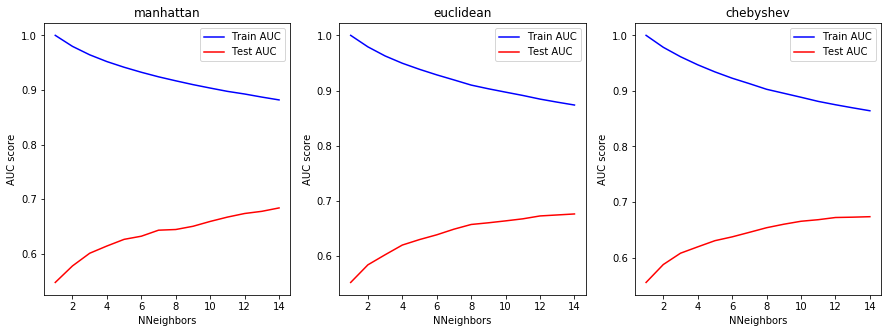

In [42]:
fig, axs = plt.subplots(1, 3, figsize=(15,5))

for i in range(len(axs)):
    axs[i].plot(n_neighbors, train_results[metrics[i]],
                'b', label='Train AUC')
    axs[i].plot(n_neighbors, test_results[metrics[i]],
                'r', label='Test AUC')
    axs[i].legend()
    axs[i].set_title(metrics[i])
    axs[i].set_ylabel('AUC score')
    axs[i].set_xlabel('NNeighbors')